# Perfume E-Commerce Market Analysis

## Dataset Overview
The Perfume E-Commerce Dataset 2024 contains detailed information about perfume listings collected from eBay, divided into two datasets: men’s perfumes and women’s perfumes, each with approximately 1,000 listings.
The dataset provides valuable insights into the online fragrance market, including product pricing, sales performance, inventory availability, brands, perfume types, and geographical distribution.

This project focuses on understanding the relationship between pricing, demand, inventory, brands, and consumer behavior in the perfume e-commerce industry through exploratory data analysis and business-oriented insights.

## Project Objective

The global perfume market on e-commerce platforms is highly competitive, with products spanning multiple price ranges, fragrance types, and luxury brands. Understanding which products sell the most, which brands generate the highest revenue, and how inventory behaves is essential for improving pricing strategies and inventory management.

In this notebook, we perform a comprehensive market analysis of perfume listings to uncover key sales patterns and business opportunities. The analysis explores:

- Pricing behavior and demand concentration
- Brand performance by sales and revenue
- Best-selling perfume types
- Inventory imbalances and stock shortages
- Geographic demand distribution
- High-performing and underperforming products

By combining exploratory analysis with business interpretation, this project aims to transform raw marketplace data into actionable insights.

## Key Questions Explored
### Pricing Analysis
- What price ranges concentrate the highest number of sales?
- Does demand decrease as prices increase?
- Which premium brands maintain strong sales despite higher prices?

### Brand & Product Analysis
- Which brands sell the most units?
- Which brands generate the highest revenue?
- Which individual products are the best sellers?
### Inventory Analysis
- Which products have high inventory but low sales?
- Which products are close to stock depletion due to high demand?
### Segmentation Analysis
- Who buys more products: men or women?
- Which perfume types (EDP, EDT, Parfum, etc.) dominate the market?
### Geographic Analysis
- Which locations generate the highest sales volume?
- Where is demand high but product availability low?

## Dataset Features

The dataset includes the following variables:

| Column         | Description                            |
| -------------- | -------------------------------------- |
| `brand`        | Perfume brand                          |
| `title`        | Product listing title                  |
| `type`         | Perfume type (EDP, EDT, Cologne, etc.) |
| `price`        | Product price                          |
| `available`    | Current inventory available            |
| `sold`         | Units sold                             |
| `itemLocation` | Seller location                        |
| `lastUpdated`  | Last listing update timestamp          |


Additional derived metrics such as revenue (price * sold) and cleaned categorical variables were also created during the analysis process.

## 0 . INITIALIZATION

In [349]:
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt

## 1. DATA LOAD


In [350]:
df_men = pd.read_csv("/Users/usr/Desktop/perfume_ecommerce/ebay_mens_perfume.csv")
print("DATA EXPLORATION DF_MEN")
print()
df_men.info()


DATA EXPLORATION DF_MEN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [351]:
# Check for nulls in "available"
null_aviable_men = df_men[df_men["available"].isna()]
null_aviable_men.head(10)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
7,Unbranded,Parfums De-Marly-Haltane Eau de Parfum spray 4...,Eau de Parfum,85.00,US $85.00,NaN,Last One / 6 sold,6.0,"May 24, 2024 00:10:39 PDT","Ithaca, New York, United States"
20,Dolce & Gabbana,Light Blue by Dolce & Gabbana 4.2 oz Cologne f...,Eau de Toilette,29.94,US $29.94/ea,NaN,"Limited quantity available / 9,208 sold",9208.0,"May 23, 2024 20:04:11 PDT","Hackensack, New Jersey, United States"
29,Penhaligon's,Penhaligon's The Tragedy of Lord George 2.5oz ...,Eau de Parfum,99.99,US $99.99,NaN,Last One / 30 sold,30.0,"May 20, 2024 04:16:27 PDT","Brenham, Texas, United States"
36,Rasasi,Rasasi Men's Hawas EDP Spray 3.4 oz Fragrances...,Eau de Parfum,45.11,US $45.11,NaN,Limited quantity available / 258 sold,258.0,"May 24, 2024 09:50:28 PDT","Brooklyn, New York, United States"
37,Maison Alhambra,Maison Alhambra Men's Victorioso Victory EDP S...,Fragrances,19.73,US $19.73,NaN,Limited quantity available / 55 sold,55.0,"May 24, 2024 07:02:34 PDT","Brooklyn, New York, United States"
39,Calvin Klein,Eternity for Men by Calvin Klein cologne EDT 6...,Eau de Toilette,40.60,US $40.60/ea,NaN,"Limited quantity available / 5,582 sold",5582.0,"May 24, 2024 09:35:06 PDT","Dallas, Texas, United States"
40,UOMO,Valentino Uomo EDT Perfume For Men 3.4oz / 100...,Eau de Toilette,54.99,US $54.99,NaN,Last One / 8 sold,8.0,"May 22, 2024 19:02:53 PDT","Peekskill, New York, United States"
42,Armaf,Club de Nuit Sillage by Armaf 3.6 oz EDP Colog...,Eau de Parfum,34.84,US $34.84/ea,NaN,"Limited quantity available / 4,460 sold",4460.0,"May 24, 2024 07:32:37 PDT","Hackensack, New Jersey, United States"
44,Azzaro,Chrome by Azzaro 6.7 / 6.8 oz EDT Cologne for ...,Eau de Toilette,46.33,US $46.33/ea,NaN,"Limited quantity available / 30,655 sold",30655.0,"May 24, 2024 07:58:01 PDT","Hackensack, New Jersey, United States"


In [352]:
df_women= pd.read_csv("/Users/usr/Desktop/perfume_ecommerce/ebay_womens_perfume.csv")
print("DATA EXPLORATION DF_WOMEN")
print()
df_women.info()

DATA EXPLORATION DF_WOMEN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               998 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          869 non-null    float64
 6   availableText      992 non-null    object 
 7   sold               984 non-null    float64
 8   lastUpdated        927 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [353]:
# Check for nulls in "available"
null_aviable_women = df_women[df_women["sold"].isna()]
null_aviable_women.head(30)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
4,Khadlaj,Shiyaaka for Men EDP Spray 100ML (3.4 FL.OZ) B...,Eau de Parfum,29.99,US $29.99/ea,10.0,More than 10 available,NaN,NaN,"Little Ferry, New Jersey, United States"
114,PRADA,Prada Paradoxe EDP Mini Bottle 7ml/.23oz,Eau de Parfum,19.00,US $19.00,10.0,More than 10 available,NaN,"May 23, 2024 06:27:16 PDT","Bowling Green, Kentucky, United States"
117,Ouai,OUAI Hair & Body Mist In ST. BARTS 3.3oz / 97m...,Fragrance Mist,28.00,US $28.00/ea,2.0,2 available,NaN,NaN,"Beverly Hills, California, United States"
121,Ellis Brooklyn,NWB Ellis Brooklyn Miami Nectar Eau de Parfum ...,Eau de Parfum,33.00,US $33.00,NaN,NaN,NaN,NaN,"Cranford, New Jersey, United States"
432,Maison Alhambra,DELILAH PERFUME EDP 3.4 OZ BY MAISON ALHAMBRA ...,Eau de Parfum,23.99,US $23.99,10.0,More than 10 available,NaN,NaN,"New York, New York, United States"
496,Victoria's Secret,Victoria's Secret Bombshell Sundrenched Eau De...,Eau de Parfum,59.99,US $59.99/ea,4.0,4 available,NaN,NaN,"Colorado Springs, Colorado, United States"
551,Jean couturier,CORIANDRE by JEAN COUTURIER for Women 30ml-1oz...,Eau de Toilette,21.95,US $21.95/ea,5.0,5 available,NaN,NaN,"Los Angeles, California, United States"
602,Giardini Di Toscana,Bianco Latte EDP by Giardini Di Toscana 100 M...,Perfume,140.00,US $140.00,NaN,NaN,NaN,NaN,"Houston, Texas, United States"
617,Dossier,Dossier MUSKY MUSK Eau de Parfum 1.7 Fl oz / 5...,Eau de Parfum,20.00,US $20.00/ea,10.0,More than 10 available,NaN,NaN,"Los Angeles, California, United States"
732,CHANEL,CHANEL Les Eaux De Chanel Paris Eau De Toilett...,Eau de Toilette,24.00,US $24.00,NaN,NaN,NaN,NaN,"Los Angeles, California, United States"


# 2. Handling missing values
a. brand = "Unknown"

b. type = "Unknown"

c. lastUpdate, "The column will be converted to datetime format, and any missing entries will be represented as NaT."

d. sold, "Sales information will be taken from availableText. If it's missing, it will be set to 0."

e. available, "Stock levels will be estimated based on availableText keywords (e.g., 'Last One' as 1). Any remaining missing values or 'Unknown' entries will be set to 0."


In [354]:
# Handling missing values in df_men
# a & b. Fill brand and type with "Unknown"
df_men["brand"] = df_men["brand"].fillna("Unknown")
df_men["type"] = df_men["type"].fillna("Unknown")
# c. Convert lastUpdated to datetime, missing entries will be represented as NaT
df_men["lastUpdated"] = df_men["lastUpdated"].str.replace(r"\s[A-Z]{3}$", "", regex=True)
df_men["lastUpdated"] = pd.to_datetime(df_men["lastUpdated"], errors="coerce")
print(df_men["lastUpdated"].head())

0   2024-05-24 10:03:04
1   2024-05-23 23:07:49
2   2024-05-22 21:55:43
3   2024-05-24 03:30:43
4   2024-05-24 07:56:25
Name: lastUpdated, dtype: datetime64[ns]


In [355]:
# d. Extract numbers from the text column
df_men["sold"] = df_men["availableText"].str.extract("(\d+) sold").astype(float)
# If no data was found (NaN), fill it with 0
df_men["sold"] = df_men["sold"].fillna(0)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7y/pcn9lmqd35j_x6mpqxv6n7fc0000gp/T/ipykernel_2048/4011208654.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_men["sold"] = df_men["availableText"].str.extract("(\d+) sold").astype(float)


In [356]:
# e. Handling missing values in the 'available' column
# If it says "Last One", stock will be 1
df_men.loc[df_men["availableText"].str.contains("Last One", na=False), "available"] = 1

# If it says "Limited quantity", assign 5 (# This value was chosen based on the lower percentiles to represent a conservative low-stock estimate.)
df_men.loc[df_men["availableText"].str.contains("Limited quantity", na=False), "available"] = 5

# If it says  "More than 10", we assing 11
df_men.loc[df_men["availableText"].str.contains("More than 10", na=False), "available"] = 11

# Fill null availableText with "Unknown"
df_men["availableText"] = df_men["availableText"].fillna("Unknown")
df_men.loc[df_men["availableText"].str.contains("Unknown", na=False), "available"] = 0


In [357]:
# Handling missing values in df_women
# a & b. Fill brand and type with "Unknown"
df_women["brand"] = df_women["brand"].fillna("Unknown")
df_women["type"] = df_women["type"].fillna("Unknown")
# c. Convert lastUpdated to datetime, missing entries will be represented as NaT
df_women["lastUpdated"] = df_women["lastUpdated"].str.replace(r"\s[A-Z]{3}$", "", regex=True)
df_women["lastUpdated"] = pd.to_datetime(df_women["lastUpdated"], errors="coerce")
print(df_women["lastUpdated"].head())

0   2024-05-23 10:43:50
1   2024-05-24 00:15:48
2   2024-05-14 20:54:25
3   2024-05-23 01:23:05
4                   NaT
Name: lastUpdated, dtype: datetime64[ns]


In [358]:
# d. Extract numbers from the text column
df_women["sold"] = df_women["availableText"].str.extract("(\d+) sold").astype(float)
# If no data was found (NaN), fill it with 0
df_women["sold"] = df_women["sold"].fillna(0)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7y/pcn9lmqd35j_x6mpqxv6n7fc0000gp/T/ipykernel_2048/827075263.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_women["sold"] = df_women["availableText"].str.extract("(\d+) sold").astype(float)


In [359]:
# e. Handling missing values in the 'available' column
# If it says "disponibles", stock will be the same number than "disponibles"
df_women_available = df_women["availableText"].str.extract("(\d+) disponibles").astype(float)
# If no data was found (NaN), fill it with 0
df_women["available"] = df_women["available"].fillna(df_women_available[0])

# If it says "Last One", stock will be 1
df_women.loc[df_women["availableText"].str.contains("Last One", na=False), "available"] = 1

# If it says "Limited quantity", assign 5 (# This value was chosen based on the lower percentiles to represent a conservative low-stock estimate.)
df_women.loc[df_women["availableText"].str.contains("Limited quantity", na=False), "available"] = 5

# If it says  "More than 10", we assing 11
df_women.loc[df_women["availableText"].str.contains("More than 10", na=False), "available"] = 11

# Fill null availableText with "Unknown"
df_women["availableText"] = df_women["availableText"].fillna("Unknown")
df_women.loc[df_women["availableText"].str.contains("Unknown", na=False), "available"] = 0
df_women.loc[df_women["availableText"].str.contains("Out of Stock", na=False), "available"] = 0

# Extract both values: number of lots and items per lot
lots_data = df_women["availableText"].str.extract(r"(\d+)\s+lots available\s+\((\d+)\s+items per lot\)").astype(float)
total_from_lots = lots_data[0] * lots_data[1]
df_women["available"] = df_women["available"].fillna(total_from_lots)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/7y/pcn9lmqd35j_x6mpqxv6n7fc0000gp/T/ipykernel_2048/4251871655.py:3: SyntaxWarning: invalid escape sequence '\d'
  df_women_available = df_women["availableText"].str.extract("(\d+) disponibles").astype(float)


# Check for duplicate rows in the dataset

In [360]:
# Check for duplicate rows in the dataset
print("Duplicate rows in the df_men", df_men.duplicated().sum())
print("Duplicate rows in the df_women", df_women.duplicated().sum())

df_women = df_women.drop_duplicates()
print("Duplicate rows in the df_women", df_women.duplicated().sum())

Duplicate rows in the df_men 0
Duplicate rows in the df_women 1
Duplicate rows in the df_women 0


In [361]:
sorted(df_men["brand"].unique())

['2nd To None',
 'AS PHOTOS',
 'AS PICTURE SHOWN',
 'AS SHOW',
 'AS SHOWN',
 'AXE',
 'Abercrombie & Fitch',
 'Acqua Di Gio',
 'Acqua di Parma',
 'Afnan',
 'Al Haramain',
 'Al Rehab',
 'Al Wataniah',
 'Alexandria Fragrances',
 'Allsaints',
 'Amouage',
 'Arabian Oud',
 'Aramis',
 'Ard Al Zaafaran',
 'Armaf',
 'As Picture Show',
 'As Picture Shown',
 'As Show',
 'As Shown',
 'As picture show',
 'As shown',
 'Assorted',
 'Avon',
 'Azzaro',
 'BHARARA',
 'BOD man',
 'BRUT',
 'Baron',
 'Bath & Body Works',
 'Bentley',
 'Bharara',
 'Blue Perfumes',
 'Bond No. 9',
 'Boucheron',
 'Branded',
 'Brut',
 'Burberry',
 'Bvlgari',
 'By Al Hambra',
 'C.K',
 'CHANEL',
 'CHRISTIAN DIOR',
 'CURVE',
 'Calvin Klein',
 'Carolina Herrera',
 'Cartier',
 'Chanel',
 'Christian Dior',
 'Classic Brands',
 'Claude Marsal',
 'Clinique',
 'Clive Christian',
 'Coach',
 'Cologne',
 'Coty',
 'Coty Inc.',
 'Creed',
 'Cuba',
 'Dana',
 'David Beckham',
 'Davidoff',
 'Designer Series',
 'Diesel',
 'Dior',
 'Does not apply',


In [362]:
df_men["brand"] = df_men["brand"].str.lower().str.strip()
df_women["brand"] = df_women["brand"].str.lower().str.strip()


In [363]:
noise_brand = [
    "as picture", "as picture shown", "as picture show",
    "as shown", "as show", "as showed",
    "as photos", "as photo",
    "assorted", "multiple brands,"
    "does not apply", "fragance", "fragrance"
]

df_men["brand"] = df_men["brand"].replace(noise_brand, "unknown")

In [364]:
# quitar acentos
def quitar_acentos(texto):
    if isinstance(texto, str):
        return ''.join(
            c for c in unicodedata.normalize('NFKD', texto)
            if not unicodedata.combining(c)
        )
    return texto

df_men["brand"] = df_men["brand"].apply(quitar_acentos)

# 2. Reemplazos directos (diccionario)

reemplazos = {
    # YSL
    "ysl": "yves saint laurent",

    # Viktor & Rolf
    "victor & rolf": "viktor & rolf",

    # Ralph Lauren
    "polo ralph lauren": "ralph lauren",
    "polo": "ralph lauren",

    # Montblanc
    "mont blanc": "montblanc",
    "mont blanc legend": "montblanc",

    # Michael Malul
    "michael malul london": "michael malul",
    "michael malul gents scents": "michael malul",

    # Mercedes
    "mercedes benz": "mercedes-benz",

    # Kenneth Cole
    "kenneth cole reaction": "kenneth cole",

    # Guerlain
    "guerlain paris": "guerlain",

    # Giorgio Armani
    "giorgio arm.ani": "giorgio armani",

    # Fragrance One (corrección)
    "fragance one": "fragrance one",

    # Estee Lauder
    "estee lauder": "estee lauder'",

    # Dolce & Gabbana
    "dolce&gabbana": "dolce & gabbana",

    # Coty
    "coty inc.": "coty",

    # Calvin Klein
    "c.k": "calvin klein",
    "ck": "calvin klein"
}

df_men["brand"] = df_men["brand"].replace(reemplazos)


In [365]:
df_men["brand"].nunique()

204

In [366]:
noise_brand_women = [
    "as picture", "as picture shown", "as picture show",
    "as shown", "as show", "as showed",
    "as photos", "as photo",
    "assorted", "multiple brands",
    "does not apply", "fragance", "fragrance",
    "see photo", "asst", "generic", "unbranded",
    "perfume", "parfum", "parfums", "designer series"
]

df_women["brand"] = df_women["brand"].replace(noise_brand_women, "unknown")

In [367]:
# quitar acentos
def quitar_acentos(texto):
    if isinstance(texto, str):
        return ''.join(
            c for c in unicodedata.normalize('NFKD', texto)
            if not unicodedata.combining(c)
        )
    return texto

df_women["brand"] = df_women["brand"].apply(quitar_acentos)

reemplazos_women = {

    # YSL
    "ysl": "yves saint laurent",

    # Dolce & Gabbana
    "dolce gabbana": "dolce & gabbana",
    "dolce&gabbana": "dolce & gabbana",

    # Giorgio Armani (errores)
    "giorgio arm.ani": "giorgio armani",
    "giorgi^o armani": "giorgio armani",
    "giorgio² armani": "giorgio armani",
    "giorgio2 armani": "giorgio armani",


    # Estee Lauder
    "estee lauder": "estee lauder",

    # Chloe / Lancome / Hermes (acentos ya removidos)
    "chloe": "chloe",
    "lancome": "lancome",
    "hermes": "hermes",

    # Viktor & Rolf
    "victor & rolf": "viktor & rolf",

    # Maison Margiela
    "maison martin margiela": "maison margiela",

    # Lattafa
    "lattafa perfumes": "lattafa",

    # Huda Beauty
    "huda beauty kayali": "huda beauty",

    # Kate Spade
    "kate spade new york": "kate spade",

    # Tiffany
    "tiffany & co.": "tiffany & co",

    # Billie Eilish
    "bellie eilish": "billie eilish",

    # Alhambra
    "al hambra": "maison alhambra",

    # Calvin Klein
    "c.k": "calvin klein",
    "ck": "calvin klein",

    # JLO
    "j lo": "jennifer lopez",
    "jlo": "jennifer lopez",

    # Armand Dupree
    "fuller armand dupree": "armand dupree",

    # Elizabeth & James
    "elizabeth and james nirvana": "elizabeth & james",

    # limpiar símbolos raros
    "~ crepe erase ~": "crepe erase"
}

df_women["brand"] = df_women["brand"].replace(reemplazos_women)

In [368]:
sorted(df_women["brand"].unique())

['acqua di parma',
 'adam levine',
 'aerin',
 'aeropostale',
 'afnan',
 'ainash perfums',
 'al haramain',
 'al rehab',
 'al wataniah',
 'al-rehab',
 'alfred sung',
 'alt fragrances',
 'anna sui',
 'aquolina',
 'ariana grande',
 'armaf',
 'armand dupree',
 'armand dupree fuller',
 'as  shown',
 'atelier cologne',
 'atlantic',
 'avon',
 'baby phat',
 'banana republic',
 'bath & body works',
 'benetton',
 'billie eilish',
 'boucheron',
 'britney spears',
 'burberry',
 'bvlgari',
 'byredo',
 'cacharel',
 'calvin klein',
 'carolina herrera',
 'chaka by chaka khan',
 'chanel',
 'change for women',
 'chloe',
 'chopard',
 'christian audigier',
 'classic erotica',
 'clean',
 'clinique',
 'clubman pinaud',
 'coach',
 'coty',
 'creed',
 'crepe erase',
 'daddy yankee',
 'dana',
 'davidoff',
 'dior',
 'diptyque',
 'dkny',
 'dolce & gabbana',
 'donna karan',
 'dossier',
 'elie saab',
 'elizabeth & james',
 'elizabeth arden',
 'elizabeth taylor',
 'ellis brooklyn',
 'escada',
 'estee lauder',
 'evyan

In [369]:
# CLEAN TYPE COLUMN

# convertir a minúsculas
df_men["type"] = df_men["type"].str.lower().str.strip()

# reemplazos / normalización
type_replacements = {

    # Eau de Parfum
    "eau de parfum": "eau de parfum",
    "eau de perfume": "eau de parfum",
    "eau de parfum intense": "eau de parfum",
    "eau de parfum/ eau de toilette": "eau de parfum",
    "eau de parfum, eau de toilette, eau de parfum intense": "eau de parfum",
    "le parfum": "parfum",
    "parfum": "parfum",
    "parfum intense": "parfum",
    "extrait de parfum": "parfum",
    "extrait de parfum": "parfum",
    "extrait de parfum": "parfum",

    # Eau de Toilette
    "eau de toilette": "eau de toilette",
    "eau de toillette": "eau de toilette",
    "eau de toilette intense": "eau de toilette",
    "edt": "eau de toilette",

    # Eau de Cologne
    "eau de cologne": "eau de cologne",
    "eau de cologne spray": "eau de cologne",
    "eau de cologne spray, cologne spray": "eau de cologne",
    "edc": "eau de cologne",

    # Cologne
    "cologne": "cologne",
    "cologne spray": "cologne",
    "fine cologne": "cologne",

    # Oils
    "oil": "oil",
    "body oil": "oil",
    "fragrance oil": "oil",
    "concentrated uncut pure body oil": "oil",

    # Body Spray
    "body spray": "body spray",
    "deodorant body spray": "body spray",
    "fragrance body spray": "body spray",

    # Other valid categories
    "aftershave": "aftershave",
    "gift sets": "gift set",
    "deodorant": "deodorant",
    "roll on": "roll on",
    "splash-on": "splash-on",
    "pheromone": "pheromone",

    # unknown / noise
    "fragrances": "unknown",
    "fragrance & perfume": "unknown",
    "does not apply": "unknown",
    "unknown": "unknown",
    "various": "unknown",
    "assorted": "unknown",
    "/": "unknown",
    "y": "unknown",

    # títulos mal puestos
    "~ the one eau de parfum spray ~": "eau de parfum",
    "jo malone cologne intense spray": "cologne",
    "dior homme cologne": "cologne",
    "de nuit": "unknown",
    "editions parfums": "unknown"
}

# aplicar reemplazos
df_men["type"] = df_men["type"].replace(type_replacements)

# revisar resultados
sorted(df_men["type"].dropna().unique())

['aftershave',
 'body spray',
 'car air freshener',
 'cologne',
 'deodorant',
 'eau de cologne',
 'eau de parfum',
 'eau de toilette',
 'eau de toilette, cologne spray',
 'eau de toilette, eau de parfum, eau de parfum intense',
 'elixir',
 'elixir de parfum',
 'fragrance rolling ball',
 'gift set',
 'oil',
 'parfum',
 'perfume',
 'pheromone',
 'roll on',
 'splash-on',
 'unknown',
 'unscented']

In [370]:
# CLEAN TYPE COLUMN WOMEN

# convertir a minúsculas
df_women["type"] = df_women["type"].str.lower().str.strip()

# reemplazos
type_replacements_women = {

    # Eau de Parfum
    "eau de parfum": "eau de parfum",
    "eau de parfume": "eau de parfum",
    "eau de perfume": "eau de parfum",
    "eau de parfum, eau de parfume": "eau de parfum",
    "eau de parfum, spray": "eau de parfum",
    "eau de parfum/perfume": "eau de parfum",
    "eau de parfum supreme": "eau de parfum",
    "edp": "eau de parfum",
    "edp and parfum": "eau de parfum",
    "l'eau de parfum": "eau de parfum",
    "l'eau de parfum": "eau de parfum",
    "elixir de parfum": "parfum",
    "esprit de parfum": "parfum",

    # Parfum
    "parfum": "parfum",
    "extract parfum": "parfum",
    "extrait de parfum": "parfum",
    "perfume": "parfum",
    "perfume, eau de parfum": "parfum",

    # Eau de Toilette
    "eau de toilette": "eau de toilette",
    "eau de toilette, spray": "eau de toilette",
    "eau de toilette spray 3.4 oz": "eau de toilette",
    "eau de toilette spray": "eau de toilette",
    "eau de toilette": "eau de toilette",
    "edt": "eau de toilette",
    "toilette spray": "eau de toilette",

    # Cologne
    "eau de cologne": "eau de cologne",
    "eau de cologne": "eau de cologne",
    "cologne": "cologne",
    "cologne spray": "cologne",

    # Mist / Spray
    "fragrance mist": "body mist",
    "fine fragrance mist": "body mist",
    "perfume fragrance mist": "body mist",
    "body mist": "body mist",
    "fragrance body mist": "body mist",
    "mist": "body mist",
    "body spray": "body spray",
    "spray": "body spray",

    # Oils
    "perfume oil": "oil",
    "oil perfume": "oil",
    "bath oil": "oil",
    "scented oils": "oil",
    "shimmering body oil": "oil",

    # Sets
    "gift sets": "gift set",
    "perfume gift sets": "gift set",
    "discovery set": "gift set",
    "3 pc": "gift set",
    "eau de parfum 2 pcs set": "gift set",
    "eau de parfum 3 pcs set": "gift set",

    # Body care
    "body lotion": "body care",
    "lotion": "body care",
    "cream": "body care",
    "sensuous body moisturizer": "body care",
    "skin_moisturizer": "body care",
    "body powder": "body care",

    # Deodorant
    "deodorant": "deodorant",
    "deodorant stick": "deodorant",

    # Other
    "hair perfume": "hair perfume",
    "solid perfume stick": "solid perfume",
    "shimmer": "body shimmer",

    # Unknown / noise
    "fragrances": "unknown",
    "beauty": "unknown",
    "does not apply": "unknown",
    "does not apply": "unknown",
    "unknown": "unknown",
    "asst": "unknown",
    "/": "unknown",
    "1": "unknown",

    # títulos mal puestos
    "~ body firm advanced body repair treatment ~": "body care",
    "pink sugar": "parfum"
}

# aplicar reemplazos
df_women["type"] = df_women["type"].replace(type_replacements_women)

# revisar resultados
sorted(df_women["type"].dropna().unique())

['body care',
 'body mist',
 'body shimmer',
 'body spray',
 'cologne',
 'deodorant',
 'eau de cologne',
 'eau de parfum',
 'eau de parfum spray (unisex tester) 3.4 oz',
 'eau de toilette',
 'gift set',
 'hair perfume',
 'oil',
 'parfum',
 'parfum, lotion, gloss and blush',
 'solid perfume',
 'unknown']

In [371]:
df_men["itemLocation"].unique()

array(['Allen Park, Michigan, United States', 'Atlanta, Georgia, Canada',
       'Dearborn, Michigan, United States',
       'Reinholds, Pennsylvania, United States',
       'Brooklyn, New York, United States',
       'Houston, Texas, United States',
       'Englewood Cliffs, New Jersey, United States',
       'Ithaca, New York, United States', 'shanghai, China',
       'Dearborn Heights, Michigan, United States',
       'Ecorse, Michigan, United States',
       'Warren, Michigan, United States',
       'San Francisco, California, United States',
       'Dayton,New Jersey, Hong Kong',
       'San Jose, California, United States',
       'Miami, Florida, United States',
       'Hamtramck, Michigan, United States',
       'Flat Lick, Kentucky, United States',
       'Elmhurst, New York, United States',
       'Hackensack, New Jersey, United States',
       'Dallas, Texas, United States',
       'Pomona, California, United States', 'Katy, Texas, United States',
       'College Point, New 

In [372]:
# country limpia
df_men["country"] = df_men["itemLocation"].str.lower()

# normalizar nombres
df_men["country"] = df_men["country"].str.replace("hongkong", "hong kong")
df_men["country"] = df_men["country"].str.replace("united states, united states", "united states")

# extraer país
def extract_country(location):

    if pd.isna(location):
        return "unknown"

    if "hong kong" in location:
        return "hong kong"

    elif "united states" in location or "usa" in location:
        return "united states"

    elif "canada" in location:
        return "canada"

    elif "china" in location:
        return "china"

    elif "taiwan" in location:
        return "taiwan"

    elif "puerto rico" in location:
        return "puerto rico"

    elif "india" in location:
        return "india"

    elif "poland" in location:
        return "poland"

    elif "israel" in location:
        return "israel"

    elif "brazil" in location:
        return "brazil"

    elif "portugal" in location:
        return "portugal"

    else:
        return "other"

df_men["country"] = df_men["country"].apply(extract_country)

In [373]:
df_men["country"].value_counts()

country
united states    916
hong kong         55
canada            11
china              8
taiwan             3
india              3
poland             2
brazil             1
portugal           1
Name: count, dtype: int64

In [374]:
df_women["itemLocation"].unique()

array(['Thomasville, Alabama, United States', 'New Jersey, Hong Kong',
       'Orange, New Jersey, United States', 'USA, New Jersey, Hong Kong',
       'Little Ferry, New Jersey, United States',
       'Warren, Michigan, United States',
       'Astoria, New York, United States',
       'Dexter, Michigan, United States',
       'Jamaica, New York, United States',
       'New York, New York, United States',
       'Ecorse, Michigan, United States', 'Quinlan, Texas, United States',
       'Cincinnati, Ohio, United States',
       'Edison, New Jersey, United States', 'New York,USA, Hong Kong',
       'Albany, New York, United States',
       'Oklahoma City, Oklahoma, United States',
       'Melrose Park, Illinois, United States', 'shanghai, China',
       'Stuyvesant Falls, New York, United States',
       'Macomb, Michigan, United States',
       'California or Hong Kong, Hong Kong',
       'Farmington, Michigan, United States',
       'Hackensack, New Jersey, United States',
       'Prin

In [420]:
# crear copia limpia
df_women["country"] = df_women["itemLocation"].str.lower()

# normalizar textos
df_women["country"] = df_women["country"].str.replace("hongkong", "hong kong")
df_women["country"] = df_women["country"].str.replace("united stated", "united states")
df_women["country"] = df_women["country"].str.replace("estados unidos", "united states")

# función para extraer país
def extract_country(location):

    if pd.isna(location):
        return "unknown"

    if "hong kong" in location:
        return "hong kong"

    elif "united states" in location or "usa" in location:
        return "united states"

    elif "canada" in location:
        return "canada"

    elif "china" in location:
        return "china"

    elif "taiwan" in location:
        return "taiwan"

    elif "puerto rico" in location:
        return "puerto rico"

    elif "india" in location:
        return "india"

    elif "japan" in location:
        return "japan"

    elif "pakistan" in location:
        return "pakistan"

    elif "bulgaria" in location:
        return "bulgaria"

    else:
        return "other"

# aplicar función
df_women["country"] = df_women["country"].apply(extract_country)

df_women["country"].value_counts()

country
united states    926
hong kong         53
china              9
taiwan             4
canada             3
japan              1
india              1
pakistan           1
bulgaria           1
Name: count, dtype: int64

# EDA

An exploratory analysis will be performed below to address questions on the following topics: Pricing, Brands, Inventory, Segmentation, and Geographic data.

<span style="color:orange"> 

## Pricing
1. ¿Cuál es el rango de precio donde se concentra la mayor cantidad de ventas?
2. ¿A mayor precio, menor volumen vendido? (relación precio vs sold)
3. ¿Qué marcas tienen precios altos pero aún así venden bien?

</span>

In [421]:
# Men

df_men["price_bin"] = pd.cut(df_men["price"], bins=10)

df_men.groupby("price_bin")["sold"].sum().sort_values(ascending=False)

/var/folders/7y/pcn9lmqd35j_x6mpqxv6n7fc0000gp/T/ipykernel_2048/557046980.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_men.groupby("price_bin")["sold"].sum().sort_values(ascending=False)


price_bin
(2.744, 28.609]       70797.0
(28.609, 54.218]      62519.0
(54.218, 79.827]      24085.0
(79.827, 105.436]      8330.0
(105.436, 131.045]     2837.0
(156.654, 182.263]     1280.0
(131.045, 156.654]      944.0
(233.481, 259.09]       470.0
(182.263, 207.872]      354.0
(207.872, 233.481]       53.0
Name: sold, dtype: float64

In [422]:
# Women
df_women["price_bin"] = pd.cut(df_women["price"], bins=10)

df_women.groupby("price_bin")["sold"].sum().sort_values(ascending=False)

/var/folders/7y/pcn9lmqd35j_x6mpqxv6n7fc0000gp/T/ipykernel_2048/1857755421.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_women.groupby("price_bin")["sold"].sum().sort_values(ascending=False)


price_bin
(1.692, 31.79]      98057.0
(31.79, 61.59]      55859.0
(61.59, 91.39]       7709.0
(91.39, 121.19]      1318.0
(121.19, 150.99]      246.0
(270.19, 299.99]      101.0
(240.39, 270.19]       59.0
(150.99, 180.79]       14.0
(180.79, 210.59]        0.0
(210.59, 240.39]        0.0
Name: sold, dtype: float64

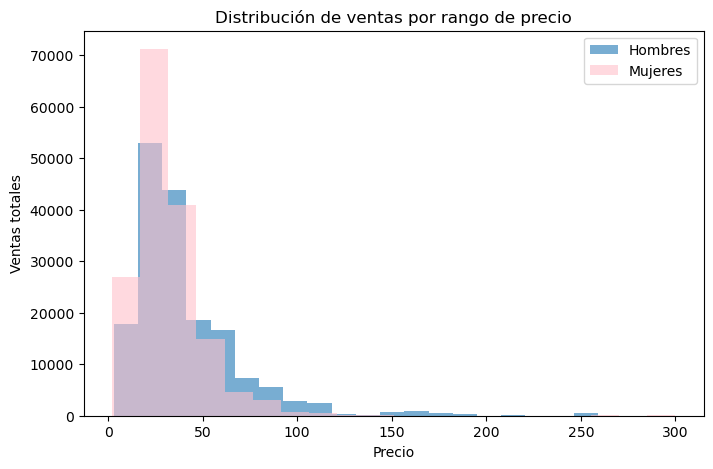

In [423]:
plt.figure(figsize=(8,5))

# Hombres
plt.hist(
    df_men["price"],
    bins=20,
    weights=df_men["sold"],
    alpha=0.6,   
    label="Hombres"
)

# Mujeres
plt.hist(
    df_women["price"],
    bins=20,
    weights=df_women["sold"],
    alpha=0.6,
    label="Mujeres",
    color="pink"
)

plt.xlabel("Precio")
plt.ylabel("Ventas totales")
plt.title("Distribución de ventas por rango de precio")

plt.legend()
plt.show()

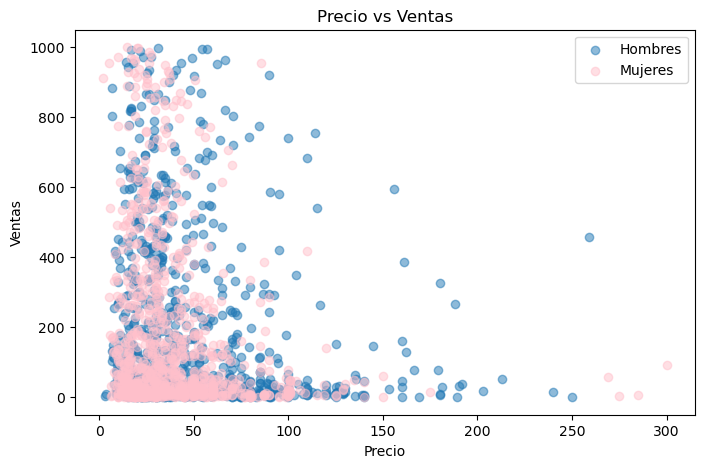

In [424]:
plt.figure(figsize=(8,5))

# Hombres
plt.scatter(
    df_men["price"],
    df_men["sold"],
    alpha=0.5,
    label="Hombres"
)

# Mujeres
plt.scatter(
    df_women["price"],
    df_women["sold"],
    alpha=0.5,
    color="pink",
    label="Mujeres"
)

plt.xlabel("Precio")
plt.ylabel("Ventas")
plt.title("Precio vs Ventas")

plt.legend()

plt.show()

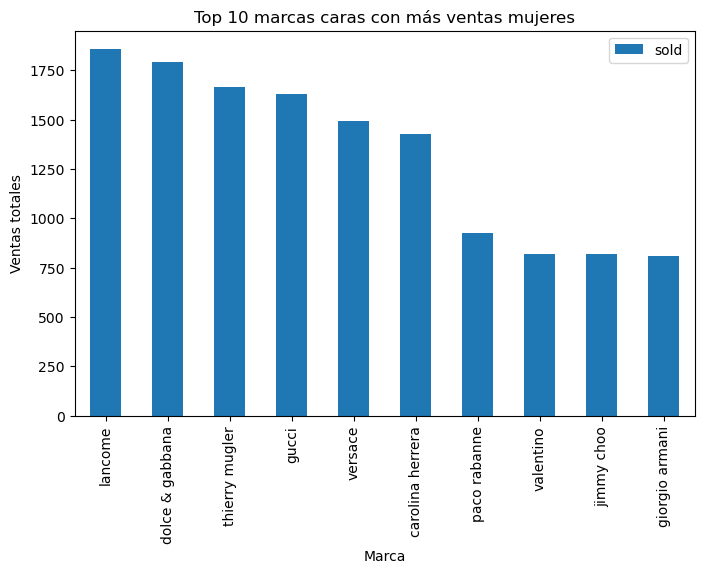

In [425]:
# Filter for "luxury" Women's brands
price_threshold_women = df_women["price"].quantile(0.75)
df_expensive_women = df_women[df_women["price"] >= price_threshold_women]

# Filter expensive brands - Women
df_brand_women = df_expensive_women.groupby("brand").agg({
    "sold": "sum"
}).sort_values(by="sold", ascending=False)

top10_women = df_brand_women.head(10)


top10_women.plot(kind="bar", figsize=(8,5))


plt.title("Top 10 marcas caras con más ventas mujeres")
plt.xlabel("Marca")
plt.ylabel("Ventas totales")



plt.xticks(rotation=90)
plt.show()

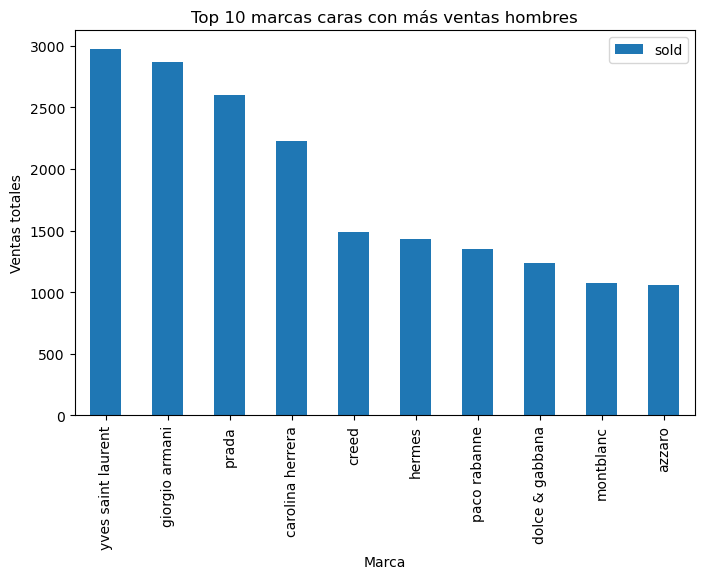

In [426]:
# Filter for "luxury" Men's brands
price_threshold_men = df_men["price"].quantile(0.75)
df_expensive_men = df_men[df_men["price"] >= price_threshold_men]

# Group by brand
df_brand_men = df_expensive_men.groupby("brand").agg({
    "sold": "sum"
}).sort_values(by="sold", ascending=False)

top10_men = df_brand_men.head(10)


top10_men.plot(kind="bar", figsize=(8,5))


plt.title("Top 10 marcas caras con más ventas hombres")
plt.xlabel("Marca")
plt.ylabel("Ventas totales")


plt.xticks(rotation=90)
plt.show()

<span style="color:green">

### 1. What is the price range where the highest number of sales is concentrated?

Most sales are concentrated in the lower and mid-price ranges for both men’s and women’s perfumes.
For men, the highest sales volume is found between approximately $3 and $54, with the strongest concentration in the $3–$29 range. After $80, sales volume decreases considerably.
For women, sales are even more concentrated in affordable products, mainly between approximately $2 and $62, especially in the $2–$32 range. Sales drop sharply after $90.
This suggests that customers are more likely to purchase perfumes within accessible price ranges, while premium products represent a smaller portion of total sales.

### 2. Does a higher price lead to lower sales volume?

Yes. The scatter plots and price distribution analysis show a clear inverse relationship between price and sales volume.
As price increases, the number of units sold generally decreases for both categories. Most high-selling products are located in the low and medium price ranges, while expensive perfumes tend to have lower sales volumes.
However, there are some exceptions where certain luxury brands maintain relatively high sales despite higher prices. This indicates that strong brand positioning and reputation can partially offset the negative effect of higher prices on demand.

### 3. Which brands have high prices but still sell well?

Some premium brands are able to maintain strong sales performance despite their higher prices.
For men, the strongest-performing premium brands include:

- Yves Saint Laurent
- Giorgio Armani
- Prada
- Carolina Herrera
- Creed
- Hermès

For women, the top premium brands include:

- Lancôme
- Dolce & Gabbana
- Thierry Mugler
- Gucci
- Versace
- Carolina Herrera

These brands combine higher prices with strong consumer demand, suggesting that brand value, prestige, and customer loyalty play an important role in purchasing behavior.

</span>

<span style="color:orange"> 

## Brands
4. What brands sell the most (volume)?
5. What brands generate the most revenue?
6. Which perfume type sells the most?
</span>

In [427]:
# 4. Brands with highest sales volume

top_brands_men = (
    df_men.groupby("brand")["sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_brands_women = (
    df_women.groupby("brand")["sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top brands men")
print(top_brands_men)

print("\nTop brands women")
print(top_brands_women)



Top brands men
brand
giorgio armani        9396.0
ralph lauren          9352.0
armaf                 9282.0
dolce & gabbana       8309.0
versace               6519.0
paco rabanne          5579.0
carolina herrera      4575.0
yves saint laurent    4438.0
calvin klein          4311.0
azzaro                4305.0
Name: sold, dtype: float64

Top brands women
brand
dolce & gabbana    8745.0
versace            8558.0
jimmy choo         6204.0
calvin klein       6100.0
burberry           5075.0
lancome            4274.0
juicy couture      4258.0
coach              3886.0
unknown            3772.0
estee lauder       3295.0
Name: sold, dtype: float64


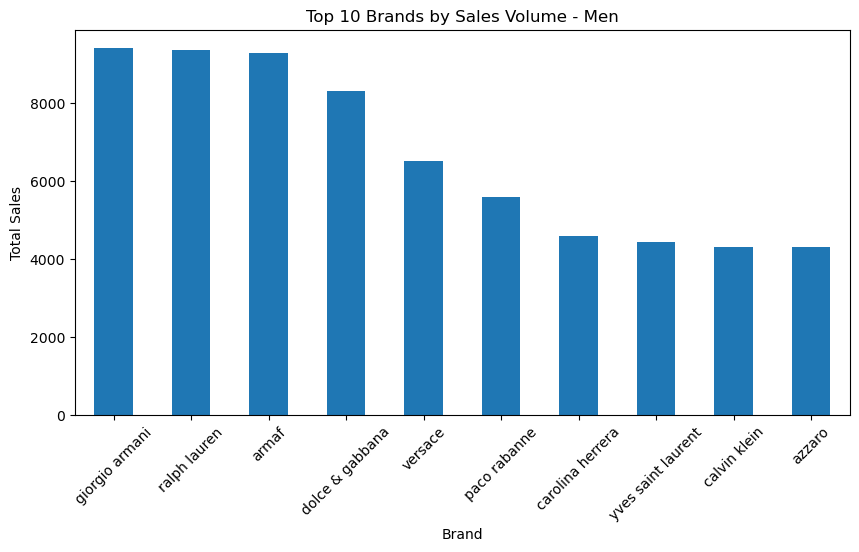

In [428]:
# Top selling brands MEN

top_brands_men.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Brands by Sales Volume - Men"
)

plt.xlabel("Brand")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

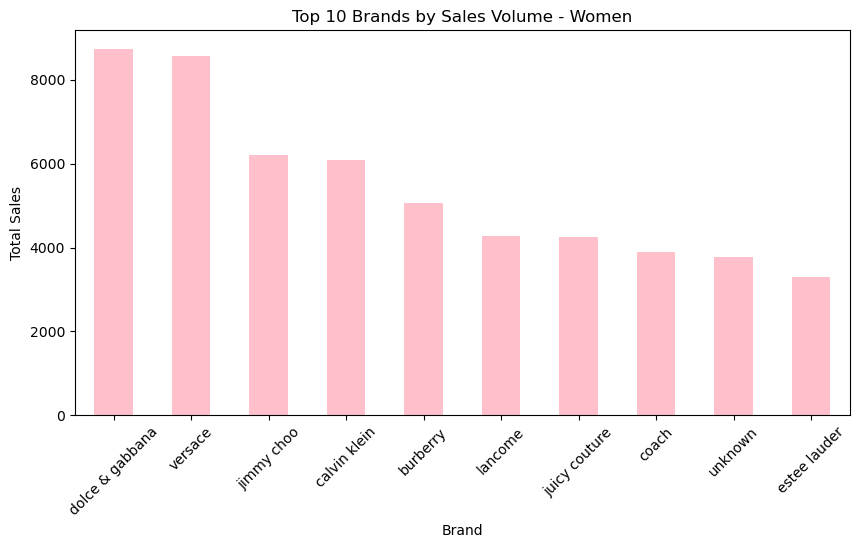

In [429]:
# Top selling brands WOMEN

top_brands_women.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Brands by Sales Volume - Women",
    color="pink"
)

plt.xlabel("Brand")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [430]:
# 5. Brands generating highest revenue
# revenue = price * sold

df_men["revenue"] = df_men["price"] * df_men["sold"]
df_women["revenue"] = df_women["price"] * df_women["sold"]

top_revenue_men = (
    df_men.groupby("brand")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_women = (
    df_women.groupby("brand")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top revenue brands men")
print(top_revenue_men)

print("\nTop revenue brands women")
print(top_revenue_women)

Top revenue brands men
brand
giorgio armani        506418.82
ralph lauren          355687.86
dolce & gabbana       348928.77
armaf                 336108.65
yves saint laurent    322787.32
creed                 317021.17
paco rabanne          265147.28
carolina herrera      248315.21
prada                 247968.65
versace               240747.83
Name: revenue, dtype: float64

Top revenue brands women
brand
dolce & gabbana     325335.20
versace             274424.45
jimmy choo          222621.20
lancome             206666.23
burberry            165410.69
carolina herrera    158613.42
thierry mugler      153548.55
calvin klein        151421.86
coach               145553.85
juicy couture       136750.07
Name: revenue, dtype: float64


type
eau de toilette                                          102123.0
eau de parfum                                             38403.0
eau de cologne                                            13613.0
perfume                                                    6225.0
parfum                                                     2700.0
unknown                                                    1826.0
cologne                                                    1302.0
oil                                                        1261.0
body spray                                                 1112.0
gift set                                                    959.0
eau de toilette, cologne spray                              823.0
unscented                                                   353.0
deodorant                                                   257.0
elixir de parfum                                            196.0
car air freshener                                           131.0
after

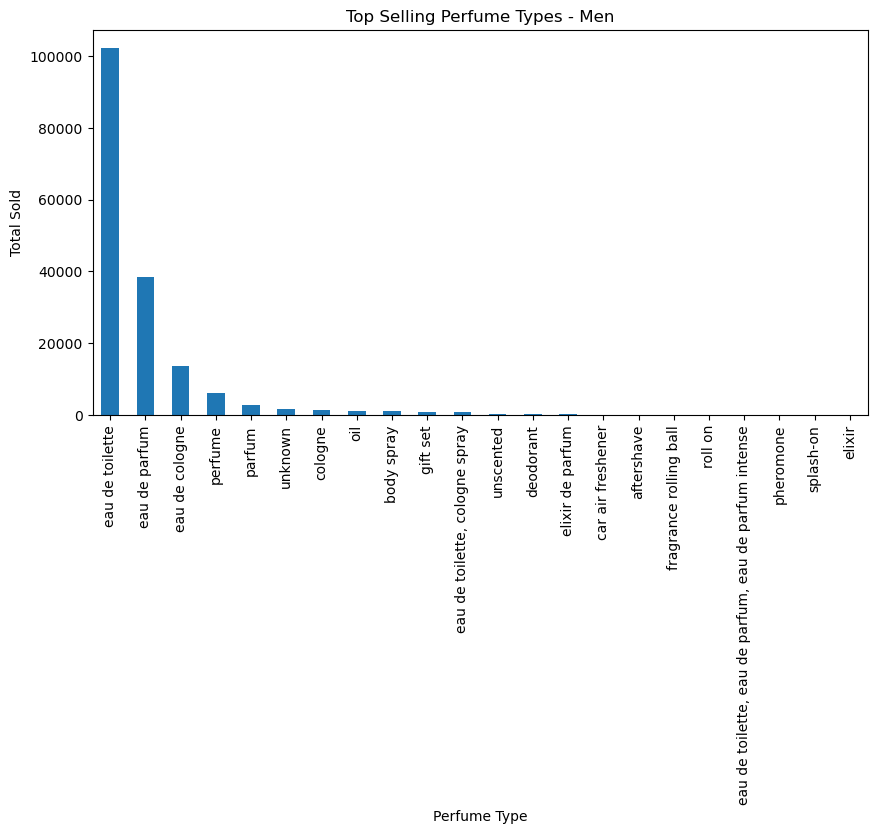

In [431]:
# TOP SELLING TYPES - MEN

top_types_men = (
    df_men
    .groupby("type")["sold"]
    .sum()
    .sort_values(ascending=False)
)

print(top_types_men)

# gráfico
plt.figure(figsize=(10,5))

top_types_men.plot(kind="bar")

plt.title("Top Selling Perfume Types - Men")
plt.xlabel("Perfume Type")
plt.ylabel("Total Sold")

plt.xticks(rotation=90)

plt.show()

type
eau de parfum                                 97110.0
eau de toilette                               48108.0
parfum                                         8246.0
eau de cologne                                 4636.0
body care                                      1031.0
body mist                                       949.0
unknown                                         814.0
oil                                             658.0
deodorant                                       452.0
body spray                                      422.0
gift set                                        299.0
cologne                                         238.0
solid perfume                                   178.0
hair perfume                                    130.0
body shimmer                                     79.0
parfum, lotion, gloss and blush                   7.0
eau de parfum spray (unisex tester) 3.4 oz        6.0
Name: sold, dtype: float64


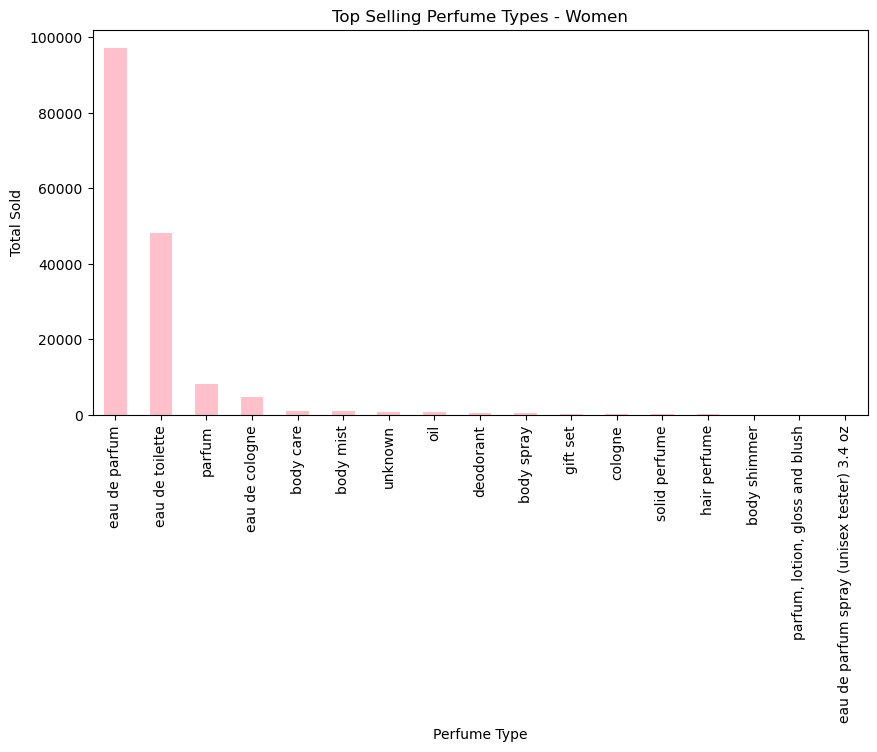

In [432]:
# TOP SELLING TYPES - WOMEN

top_types_women = (
    df_women
    .groupby("type")["sold"]
    .sum()
    .sort_values(ascending=False)
)

print(top_types_women)

# gráfico
plt.figure(figsize=(10,5))

top_types_women.plot(kind="bar", color="pink")

plt.title("Top Selling Perfume Types - Women")
plt.xlabel("Perfume Type")
plt.ylabel("Total Sold")

plt.xticks(rotation=90)

plt.show()

<span style="color:green">

### 4. Which brands sell the most? (Sales volume)

Men
The men's segment is led by premium designer brands.
Giorgio Armani had the highest sales volume with 9,396 units sold, followed closely by Ralph Lauren and Armaf.
This suggests that men’s consumers strongly prefer well-known luxury and designer fragrances.

Women
In the women’s segment, Dolce & Gabbana and Versace dominated sales volume, with more than 8,500 units sold each.
This indicates strong demand for luxury feminine fragrances, especially brands associated with fashion and prestige.

### 5. Which brands generate the most revenue?

Men
The highest revenue-generating brand in the men’s category was Giorgio Armani with more than $506K in estimated revenue.
Other high-performing brands included:

- Ralph Lauren
- Dolce & Gabbana
- Creed
- Yves Saint Laurent

This shows that premium men’s fragrances are capable of generating both high sales volume and high revenue simultaneously.

Women
For women, Dolce & Gabbana generated the highest revenue, followed by Versace and Jimmy Choo.
The women’s segment appears highly concentrated around luxury fashion fragrance brands with strong brand recognition.

### 6. Which perfume types sell the most?

Men
The most popular perfume type for men was clearly:

- Eau de Toilette → 102,123 units sold
- Eau de Parfum → 38,403 units sold
- Eau de Cologne → 13,613 units sold

This suggests that men’s consumers strongly prefer lighter and fresher fragrance formats, especially Eau de Toilette products.

Women
In contrast, women showed a different preference pattern:

- Eau de Parfum → 97,110 units sold
- Eau de Toilette → 48,108 units sold
- Parfum → 8,246 units sold

This indicates that women tend to prefer stronger and longer-lasting fragrance concentrations compared to men.

<span>

<span style="color:orange"> 

## Inventory Questions
7. Which products have high stock availability but low sales?
8. Which products are close to selling out? (high sales + low stock)

</span>

In [433]:
# HIGH STOCK + LOW SALES
# MEN

high_stock_low_sales_men = (
    df_men[
        (df_men["available"] >= 5) &
        (df_men["sold"] <= 10)
    ]
    [["brand", "title", "available", "sold", "price"]]
    .sort_values(by="available", ascending=False)
)

high_stock_low_sales_men.head(10)

,brand,title,available,sold,price
979,brut,Original Fragrance Cologne by Brut for Men - 5...,50.0,8.0,9.78
387,ulric de varens,Varens For Men Cafe Vanille Eau De Toilette fo...,49.0,1.0,22.00
778,alexandria fragrances,Alexandria fragrances: BLACK PANTHER INSPIRED ...,39.0,4.0,3.00
627,dolce & gabbana,Dolce & Gabbana K (King) Eau de Parfum Intense...,33.0,9.0,77.99
595,mercedes-benz,Mercedes Benz Club Black Eau de Toilette for M...,33.0,7.0,38.99
397,maison francis kurkdjian,Maison Francis Kurkdjian Amyris Homme 2.4oz Ea...,24.0,6.0,140.00
535,armaf,Armaf Odyssey Mandarin Sky Eau de Parfum for M...,22.0,2.0,33.99
843,giorgio armani,Armani Acqua Di Gio Parfum Refillable for Men ...,19.0,5.0,123.99
581,branded,*Perfume Para Hombre Con Feromonas De Atraer M...,13.0,1.0,17.99
662,rawchemistry,FOR HIM by RAW CHEMISRTY 30ml/1oz Peromone Col...,13.0,4.0,30.95


In [434]:
# HIGH STOCK + LOW SALES
# WOMEN

high_stock_low_sales_women = (
    df_women[
        (df_women["available"] >= 5) &
        (df_women["sold"] <= 10)
    ]
    [["brand", "title", "available", "sold", "price"]]
    .sort_values(by="available", ascending=False)
)

high_stock_low_sales_women.head(10)

,brand,title,available,sold,price
562,unknown,MOTHER'S DAY SALE DG YSL GUESS KENZO BURBERRY...,92.0,7.0,13.37
74,elizabeth arden,Elizabeth Arden White Tea Fragrance Collection...,50.0,2.0,19.45
989,dkny,Be Extra Delicious By DKNY 0.24oz EDP Women's ...,19.0,5.0,14.95
610,victoria's secret,Victoria Secret Bombshell Fragrance Mist 250ml...,11.0,3.0,18.04
737,giorgio armani,NEW Women's My Way EDP Spray 3oz Giorgio Arm.a...,11.0,3.0,38.69
735,coach,Coach Love 1.7 oz EDP Spray Womens Perfume 50 ...,11.0,7.0,48.99
697,giorgio armani,My Way Nectar Giorgio Armani EDP 0.33. Fl. Oz....,11.0,3.0,25.95
663,ainash perfums,Royal Noir Absolu by Ainash 2.5 oz Extrait de ...,11.0,3.0,58.50
646,unknown,Perfumes for women La Vida Bella 100Ml 3.4fl....,11.0,10.0,13.99
617,dossier,Dossier MUSKY MUSK Eau de Parfum 1.7 Fl oz / 5...,11.0,0.0,20.00


In [435]:
# HIGH SALES + LOW STOCK
# MEN

low_stock_high_sales_men = (
    df_men[
        (df_men["sold"] >= 500) &
        (df_men["available"] <= 5)
    ]
    [["brand", "title", "available", "sold", "price"]]
    .sort_values(by="sold", ascending=False)
)

low_stock_high_sales_men.head(10)

,brand,title,available,sold,price
777,lacoste,Lacoste Eau De Lacoste Blanc L.12.12 Cologne f...,2.0,995.0,54.50
644,curve,Curve Chill by Liz Claiborne Cologne for Men 4...,4.0,992.0,16.82
453,montblanc,Mont Blanc Explorer 6.7 oz EDP Cologne for Men...,5.0,950.0,62.08
354,paul sebastian,PS by Paul Sebastian Cologne for Men 8 / 8.0 o...,4.0,934.0,26.10
57,versace,Versace Pour Homme Signature by Versace 3.4 oz...,5.0,899.0,36.88
242,paco rabanne,1 Million by Paco Rabanne 3.4 oz EDT Cologne f...,5.0,877.0,47.99
455,ralph lauren,Polo Deep Blue by Ralph Lauren 4.2 oz Parfum C...,5.0,869.0,53.98
350,lalique,Encre Noire by Lalique Cologne for Men EDT 3.3...,5.0,866.0,26.52
58,kenneth cole,KENNETH COLE BLACK Cologne for Men 3.4 oz EDT ...,5.0,865.0,24.70
142,davidoff,Cool Water Intense by Davidoff 4.2 oz EDP Colo...,5.0,849.0,34.98


In [436]:
# HIGH SALES + LOW STOCK
# WOMEN

low_stock_high_sales_women = (
    df_women[
        (df_women["sold"] >= 500) &
        (df_women["available"] <= 5)
    ]
    [["brand", "title", "available", "sold", "price"]]
    .sort_values(by="sold", ascending=False)
)

low_stock_high_sales_women.head(10)

,brand,title,available,sold,price
367,jo malone,"Jo Malone London Cologne Spray ,Travel Size 9m...",5.0,968.0,17.00
817,versace,Red Jeans by Versus Versace 2.5 oz Perfume for...,4.0,960.0,18.81
287,thierry mugler,Alien by Thierry Mugler 3 oz EDP Perfume for W...,5.0,953.0,85.56
460,burberry,Burberry Touch by Burberry perfume for women E...,1.0,947.0,34.93
639,sarah jessica parker,LOVELY by Sarah Jessica Parker Perfume for Wom...,1.0,915.0,19.95
160,estee lauder,Pleasures by Estee Lauder 3.4 oz EDP Perfume f...,5.0,901.0,34.28
345,calvin klein,Escape by Calvin Klein EDP Perfume for Women 3...,5.0,854.0,26.66
714,dolce & gabbana,Light Blue by Dolce & Gabbana D&G 3.3 / 3.4 oz...,5.0,845.0,43.30
415,versace,VERSACE CRYSTAL NOIR by Gianni Versace for wom...,5.0,838.0,46.44
173,coach,Coach Wild Rose 3 oz EDP Perfume for Women New...,1.0,796.0,42.28


<span style="color:green">

### 7. Which products have high stock availability but low sales?

Men
Several men’s fragrances showed relatively high inventory levels but weak sales performance. For example:
Brut had 50 units available but only 8 sales.
Mercedes-Benz had 33 units available with only 7 sales.
Maison Francis Kurkdjian had 24 units available and only 6 sales despite its high price point ($140).

This may indicate:
- low customer demand,
- overstocked inventory,
- or products priced too high for their sales performance.

Women

The women’s dataset also revealed products with high stock but limited sales:
- Elizabeth Arden had 50 units available but only 2 sales.
- Victoria's Secret had 11 units available with only 3 sales.
- Dossier had 11 units available and no recorded sales.

These products may require:
- promotional campaigns,
- discounts,
- or inventory optimization strategies.

### 8. Which products are close to selling out? (high sales and low stock)

Men
Several men’s fragrances showed extremely high sales with very limited remaining stock:

- Lacoste recorded 995 sales with only 2 units remaining.
- Montblanc sold 950 units with only 5 units left.
- Versace and Paco Rabanne also showed very high demand with critically low inventory.

This suggests strong market demand and potential restocking opportunities.

Women
The women’s category showed similar behavior among highly popular products:

- Jo Malone sold 968 units with only 5 units remaining.
- Burberry sold 947 units with just 1 unit left.
- Dolce & Gabbana and Versace also showed high sales and low remaining inventory.

These products appear to be top-performing fragrances that may require urgent replenishment to avoid stockouts.

<span style="color:orange"> 

## Inventory Questions
9. Who buys more: men, women, or unisex?

</span>

In [437]:
# total ventas hombres
total_men = df_men["sold"].sum()

# total ventas mujeres
total_women = df_women["sold"].sum()

print("Men total sales:", total_men)
print("Women total sales:", total_women)

Men total sales: 171669.0
Women total sales: 163363.0


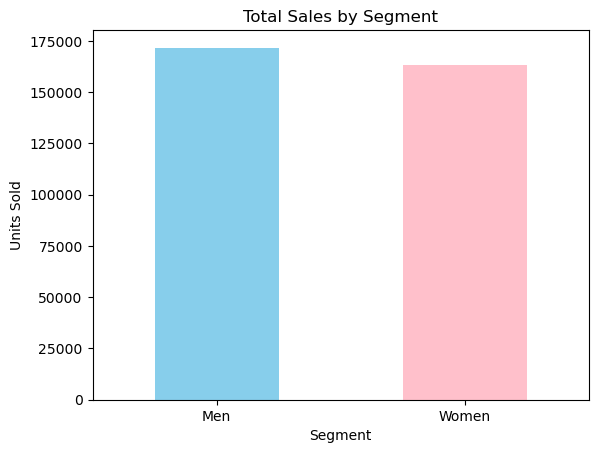

In [438]:
sales_by_segment = pd.Series({
    "Men": total_men,
    "Women": total_women
})

sales_by_segment.plot(kind="bar", color=["skyblue", "pink"])

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Units Sold")

plt.xticks(rotation=0)

plt.show()

In [439]:
# revenue total hombres
total_revenue_men = df_men["revenue"].sum()

# revenue total mujeres
total_revenue_women = df_women["revenue"].sum()

print("Men total revenue:", total_revenue_men)
print("Women total revenue:", total_revenue_women)

Men total revenue: 6939858.09
Women total revenue: 5198922.98


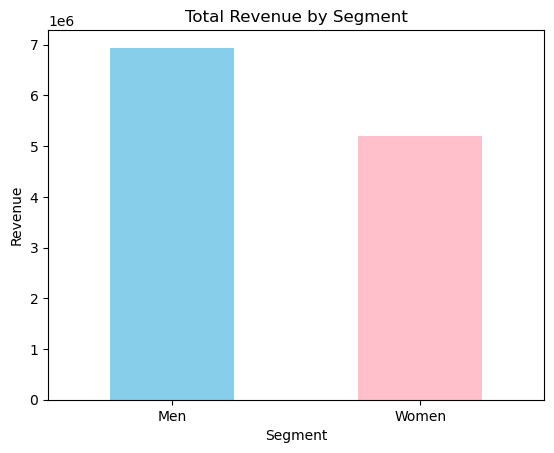

In [440]:
revenue_by_segment = pd.Series({
    "Men": total_revenue_men,
    "Women": total_revenue_women
})

revenue_by_segment.plot(kind="bar", color=["skyblue", "pink"])

plt.title("Total Revenue by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

<span style="color:green">

### 9. Who buys more: men, women, or unisex?

The analysis shows that men’s fragrances generated slightly higher sales volume than women’s fragrances.

Men total sales: 171,669 units
Women total sales: 163,363 units

However, the difference becomes more significant when analyzing total revenue:

Men total revenue: $6.94 million
Women total revenue: $5.20 million

This indicates that the men’s fragrance segment not only sold more units overall, but also generated substantially higher monetary value. This may suggest that male consumers tend to purchase higher-priced fragrances or premium luxury products more frequently.

Additionally:

Men showed stronger preference for Eau de Toilette products.
Women showed higher demand for Eau de Parfum fragrances.
Luxury designer brands such as Giorgio Armani, Dolce & Gabbana, and Versace dominated both sales volume and revenue performance.

Overall, both segments are commercially strong, but the men’s fragrance market demonstrated a stronger performance in both units sold and total revenue generated.

<span style="color:orange"> 

## Geography Questions
10. Where are the most products sold?
11. Where is demand high but availability low?
</span>

In [ ]:
# Top sales by country men

country_sales_men = (
    df_men.groupby("country")["sold"]
    .sum()
    .sort_values(ascending=False)
)

country_sales_men.head(10)

country
united states    168316.0
hong kong          1926.0
canada              565.0
india               410.0
brazil              177.0
poland              100.0
china                99.0
taiwan               46.0
portugal             30.0
Name: sold, dtype: float64

In [ ]:
# High demand + low stock by country men

high_demand_low_stock_men = df_men[
    (df_men["sold"] >= 100) &
    (df_men["available"] <= 5)
]

high_demand_low_stock_men[
    ["country", "brand", "title", "sold", "available"]
].sort_values(by="sold", ascending=False).head(10)

,country,brand,title,sold,available
777,united states,lacoste,Lacoste Eau De Lacoste Blanc L.12.12 Cologne f...,995.0,2.0
644,united states,curve,Curve Chill by Liz Claiborne Cologne for Men 4...,992.0,4.0
453,united states,montblanc,Mont Blanc Explorer 6.7 oz EDP Cologne for Men...,950.0,5.0
354,united states,paul sebastian,PS by Paul Sebastian Cologne for Men 8 / 8.0 o...,934.0,4.0
57,united states,versace,Versace Pour Homme Signature by Versace 3.4 oz...,899.0,5.0
242,united states,paco rabanne,1 Million by Paco Rabanne 3.4 oz EDT Cologne f...,877.0,5.0
455,united states,ralph lauren,Polo Deep Blue by Ralph Lauren 4.2 oz Parfum C...,869.0,5.0
350,united states,lalique,Encre Noire by Lalique Cologne for Men EDT 3.3...,866.0,5.0
58,united states,kenneth cole,KENNETH COLE BLACK Cologne for Men 3.4 oz EDT ...,865.0,5.0
142,united states,davidoff,Cool Water Intense by Davidoff 4.2 oz EDP Colo...,849.0,5.0


In [ ]:
# Top sales by country women

country_sales_women = (
    df_women.groupby("country")["sold"]
    .sum()
    .sort_values(ascending=False)
)

country_sales_women

country
united states    160658.0
hong kong          1709.0
china               586.0
bulgaria            163.0
taiwan               81.0
canada               79.0
india                43.0
japan                24.0
pakistan             20.0
Name: sold, dtype: float64

In [448]:
# High demand + low stock by country women

high_demand_low_stock_women = df_women[
    (df_women["sold"] >= 100) &
    (df_women["available"] <= 5)
]

high_demand_low_stock_women[
    ["country", "brand", "title", "sold", "available"]
].sort_values(by="sold", ascending=False).head(10)

,country,brand,title,sold,available
367,united states,jo malone,"Jo Malone London Cologne Spray ,Travel Size 9m...",968.0,5.0
817,united states,versace,Red Jeans by Versus Versace 2.5 oz Perfume for...,960.0,4.0
287,united states,thierry mugler,Alien by Thierry Mugler 3 oz EDP Perfume for W...,953.0,5.0
460,united states,burberry,Burberry Touch by Burberry perfume for women E...,947.0,1.0
639,united states,sarah jessica parker,LOVELY by Sarah Jessica Parker Perfume for Wom...,915.0,1.0
160,united states,estee lauder,Pleasures by Estee Lauder 3.4 oz EDP Perfume f...,901.0,5.0
345,united states,calvin klein,Escape by Calvin Klein EDP Perfume for Women 3...,854.0,5.0
714,united states,dolce & gabbana,Light Blue by Dolce & Gabbana D&G 3.3 / 3.4 oz...,845.0,5.0
415,united states,versace,VERSACE CRYSTAL NOIR by Gianni Versace for wom...,838.0,5.0
173,united states,coach,Coach Wild Rose 3 oz EDP Perfume for Women New...,796.0,1.0


<span style="color:green">

### 10. In which locations are the most products sold?
Men
The United States dominates men's fragrance sales with 168,316 units sold, representing almost the entire market. Other countries such as Hong Kong, Canada, and India contribute only a small fraction of total sales.
This suggests that the primary demand for men's fragrances is heavily concentrated in the U.S. market.

Women
The same pattern appears in women's fragrances. The United States leads by a very large margin with 160,658 units sold, while Hong Kong and China contribute much lower sales volumes.
Overall, both datasets show that the U.S. is the core market for fragrance sales.

### 11. Where is there high demand but low availability?
Men
Several men's fragrances show extremely high sales volumes while maintaining very low inventory levels, indicating strong demand and potential stock shortages.
Some notable examples include:

- Lacoste Eau De Lacoste Blanc (995 sold, only 2 available)
- Curve Chill by Liz Claiborne (992 sold, 4 available)
- Mont Blanc Explorer (950 sold, 5 available)
- Versace Pour Homme Signature (899 sold, 5 available)

These products may require inventory restocking to avoid missed sales opportunities.

Women
Women's fragrances also show multiple high-demand products with critically low stock levels.

Examples include:

- Jo Malone London Cologne Spray (968 sold, 5 available)
- Alien by Thierry Mugler (953 sold, 5 available)
- Burberry Touch (947 sold, only 1 available)
- Lovely by Sarah Jessica Parker (915 sold, only 1 available)

This indicates that several top-performing women's fragrances are close to selling out and may benefit from inventory replenishment strategies.

<span style="color:green">

# General Conclusion

This analysis made it possible to identify important sales patterns, customer preferences, and inventory opportunities within the fragrance market.

The results showed that low and mid-price ranges concentrate the highest sales volume, while premium brands such as Giorgio Armani, Dolce & Gabbana, Versace, Paco Rabanne, Ralph Lauren, and Creed continue generating strong revenue despite their higher prices. This suggests that well-known luxury brands maintain strong customer demand and that consumers are willing to pay more for products with stronger brand recognition and positioning.

Additionally, Eau de Toilette and Eau de Parfum were the most popular fragrance types in both men's and women's categories, representing the majority of total sales. This indicates that these formats clearly dominate customer preferences and should remain a priority in commercial and inventory strategies.

From an inventory perspective, several products showed extremely high sales with very limited availability, indicating potential stock shortages and clear opportunities for inventory expansion. Brands such as Lacoste, Versace, Paco Rabanne, Montblanc, Ralph Lauren, Jo Malone, Thierry Mugler, Burberry, Coach, and Dolce & Gabbana presented products with very high demand and critically low stock levels. This suggests that some products may already be losing potential sales due to limited availability.

On the other hand, products with high inventory levels but low sales were also identified, especially among brands and products such as Brut Original Fragrance Cologne, Varens For Men Cafe Vanille, Alexandria Fragrances Black Panther, Armaf Odyssey Mandarin Sky, Elizabeth Arden White Tea Fragrance Collection, DKNY Be Extra Delicious, and some generic fragrances classified as “unknown.” This may represent overstock problems, higher storage costs, and low inventory turnover, making it advisable to evaluate strategies such as discounts, promotions, repositioning, or inventory reduction for these cases.

Geographically, the United States overwhelmingly dominated sales volume in both categories, positioning it as the strongest market for future inventory expansion and marketing strategies. Although markets such as Hong Kong, Canada, and China showed some activity, the difference compared to the United States was considerable.

In terms of business opportunities, the analysis suggests that the best strategies would focus on:

increasing inventory for high-demand products,
prioritizing premium brands with high revenue generation,
strengthening marketing campaigns for strong-performing products,
and optimizing inventory by reducing or eliminating low-rotation products.